In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
np.random.seed(42)

In [12]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

x_train, x_test, y_train, y_test = train_test_split(X , y, test_size=0.2)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(80, 1) (80, 1)
(20, 1) (20, 1)


In [9]:
model = LinearRegression() # Loading the Linear regression model from scikit learn

In [10]:
model.fit(x_train, y_train) # finding the minimum of loss function, and returning the W and B.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
print("Coefficient (w):", model.coef_)
print("Intercept (b):", model.intercept_)

Coefficient (w): [[3.05961165]]
Intercept (b): [4.04112906]


In [ ]:
y_pred = model.predict(x_test)

print(y_pred) # prediction

[[7.67886251]
 [6.57172836]
 [4.30678005]
 [8.43227004]
 [4.6268278 ]
 [7.00005286]
 [7.01428686]
 [4.46594906]
 [4.45486544]
 [6.02579972]
 [5.94609039]
 [4.67819926]
 [5.61240222]
 [7.91552372]
 [5.49059291]
 [5.14962239]
 [8.47352004]
 [6.19278681]
 [8.42341496]
 [5.33867879]]


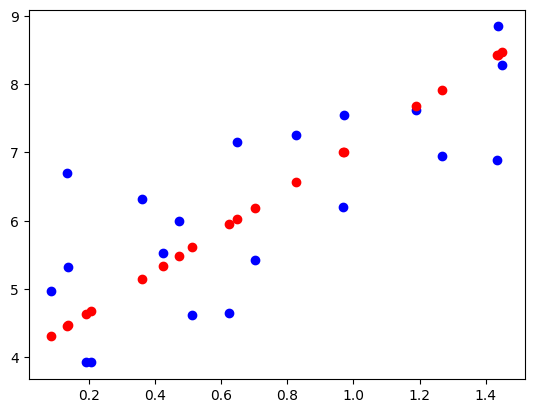

In [26]:
plt.scatter(x_test, y_test, label="Actual Data", color="blue")
plt.scatter(x_test, y_pred, color="red", label="Predicted Line")


In [28]:
# Evaluation of model

from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.913897017390717
R2 Score: 0.5066422279479312


In [32]:
from sklearn.model_selection import GridSearchCV

parameters = {
              "fit_intercept": [True, False]
             }
grid = GridSearchCV(estimator=model, param_grid = parameters, cv = 2, n_jobs=-1)

grid.fit(X=x_train, y=y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [35]:
print("Best parameters:", grid.best_params_)

print("Test score:", grid.score(x_test, y_test))

grid.cv_results_

Best parameters: {'fit_intercept': True}
Test score: 0.4529032254058557


{'mean_fit_time': array([0.00175989, 0.00125587]),
 'std_fit_time': array([0.00075495, 0.00025094]),
 'mean_score_time': array([0.0007534 , 0.00100434]),
 'std_score_time': array([2.50816345e-04, 5.96046448e-07]),
 'param_fit_intercept': masked_array(data=[True, False],
              mask=[False, False],
        fill_value=True),
 'params': [{'fit_intercept': True}, {'fit_intercept': False}],
 'split0_test_score': array([0.76146633, 0.09684373]),
 'split1_test_score': array([ 0.78902268, -0.24463219]),
 'mean_test_score': array([ 0.7752445 , -0.07389423]),
 'std_test_score': array([0.01377818, 0.17073796]),
 'rank_test_score': array([1, 2], dtype=int32)}